<a href="https://colab.research.google.com/github/Nitish-9k/ATS_System/blob/main/JupyterNotebook/BertModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(12,6)



In [ ]:
df=pd.read_csv("cleaned_resumeJD_pairs (2).csv")



---



In [ ]:

print(f"Loaded:{df.shape[0]} rows {df.shape[1]}columns")
print(f"Columns:{df.columns.tolist()}")
print(f"label distribution:")
print(df["match_label"].value_counts())
df.head()

Loaded:266 rows 7columns
Columns:['resume_text', 'job_description', 'match_score', 'match_label', 'match_lower_label', 'resume_len', 'jd_len']
label distribution:
match_label
high      107
low        81
medium     78
Name: count, dtype: int64


,resume_text,job_description,match_score,match_label,match_lower_label,resume_len,jd_len
0,Operations Analyst with 12 years of experience...,Network Engineer at nonprofit organization. Re...,0.16,low,low,36,33
1,Cybersecurity Analyst with 7 years of experien...,Financial Analyst at financial institution. Re...,0.08,low,low,38,33
2,Supply Chain Analyst with 8 years of experienc...,Registered Nurse at financial institution. Req...,0.91,high,high,52,48
3,Registered Nurse with 2 years of experience sp...,Business Intelligence Analyst at e-commerce co...,0.11,low,low,37,36
4,Financial Analyst with 9 years of experience s...,Recruiter at nonprofit organization. Required ...,0.07,low,low,36,32


In [ ]:
print(df.columns)

Index(['resume_text', 'job_description', 'match_score', 'match_label',
       'match_lower_label', 'resume_len', 'jd_len'],
      dtype='object')


In [ ]:
df.drop("match_lower_label",axis=1,inplace=True)

In [ ]:
df.columns

Index(['resume_text', 'job_description', 'match_score', 'match_label',
       'resume_len', 'jd_len'],
      dtype='object')

In [ ]:

print(f"Loaded:{df.shape[0]} rows {df.shape[1]}columns")
df.drop("match_lower_label",axis=1,inplace=True)
print(f"Columns:{df.columns.tolist()}")
print(f"label distribution:")
print(df["match_label"].value_counts())
df.head()



Loaded:266 rows 6columns


KeyError: "['match_lower_label'] not found in axis"

In [ ]:
print("Loading a bert model")
model=SentenceTransformer("all-mpnet-base-v2")
print("model Loaded")
print(f"Model:   all-mpnet-base-v2")
print(f"Parameter:  22.7m")
print(f"Max Tokens:  {model.max_seq_length}")




Loading a bert model


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

model Loaded
Model:   all-mpnet-base-v2
Parameter:  22.7m
Max Tokens:  384


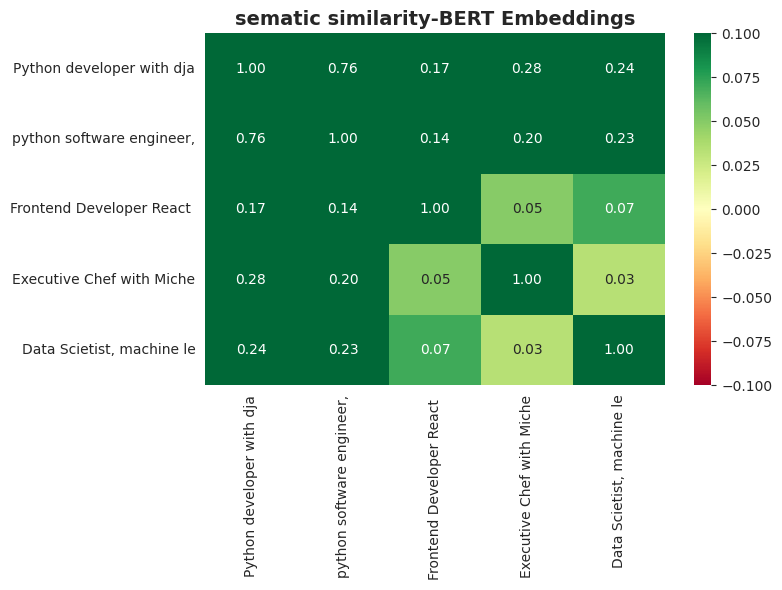

In [ ]:
texts=[
    "Python developer with django experience",
    "python software engineer, django REST APIs",
    "Frontend Developer React AND Javascript ",
    "Executive Chef with Michelin Experience",
    "Data Scietist, machine learning, pytorch",
]
embeddings=model.encode(texts)
sim_matrix=cosine_similarity(embeddings)

plt.figure(figsize=(8,6))
sns.heatmap(sim_matrix,annot=True,fmt=".2f",cmap="RdYlGn",
            xticklabels=[t[:25]for t in texts],
            yticklabels=[t[:25] for t in texts],
            vmin=0,vmax=0)
plt.title("sematic similarity-BERT Embeddings",fontsize=14,fontweight="bold")
plt.tight_layout()
plt.show()







In [ ]:
print("Generating resume embeddings")
resume_embeddings=model.encode(
    df["resume_text"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)
jd_embeddings=model.encode(
    df["job_description"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"Resume embeddings shape {resume_embeddings.shape}")
print(f"jd embeddings shape {jd_embeddings.shape}")
print(f"Each text ->{resume_embeddings.shape[1]}-dimensional vector")

Generating resume embeddings


Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Resume embeddings shape (266, 768)
jd embeddings shape (266, 768)
Each text ->768-dimensional vector


In [ ]:
# compute cosine similarity for each pair
# for each row :similarity between that resume and its paired JD
pair_similarity=[]
for i in range(len(resume_embeddings)):
  sim=cosine_similarity([resume_embeddings[i]],[jd_embeddings[i]])[0][0]
  pair_similarity.append(sim)


df["bert_similarity"]=pair_similarity
print("cosine similarity computed for all pairs")
print(df[["match_label","match_score","bert_similarity"]].head(10))





cosine similarity computed for all pairs
  match_label  match_score  bert_similarity
0         low         0.16         0.443143
1         low         0.08         0.515671
2        high         0.91         0.413812
3         low         0.11         0.418171
4         low         0.07         0.490607
5         low         0.10         0.473233
6         low         0.10         0.563516
7         low         0.12         0.682925
8        high         0.88         0.447671
9        high         0.90         0.476287


In [ ]:
# Base Model Performance :How good is bert out of the box
mae=mean_absolute_error(df["match_score"],df['bert_similarity'])
rmse=np.sqrt(mean_absolute_error(df["match_score"],df['bert_similarity']))

print("Base BERT Model Performance (Before Finetuning)")
print("="*50)
print(f"mae:{mae:.4f} (lower is better)")
print(f"rmse :{rmse:.4f} (lower is better)")

Base BERT Model Performance (Before Finetuning)
mae:0.3021 (lower is better)
rmse :0.5497 (lower is better)


In [ ]:
import pickle

with open("resume_embeddings.pkl","wb") as f:
  pickle.dump({
      "resume_embeddings":resume_embeddings,
      "jd_embeddings":jd_embeddings,
      "match_scores":df['match_score'].tolist(),
      "match_labels":df["match_label"].tolist(),
  },f)
  print("Saved: resume_embeddings.pkl")
  print(f"resume_embeddings: {resume_embeddings.shape}")
  print(f"jd_embeddings {jd_embeddings.shape}")
  print("these will be loaded")


Saved: resume_embeddings.pkl
resume_embeddings: (266, 768)
jd_embeddings (266, 768)
these will be loaded
